# Exploratory Data Analysis (EDA) - Poker Hand Dataset

Notebook này nhằm mục đích khám phá dữ liệu, kiểm tra các giá trị thiếu, phân phối của các biến và đặc biệt là sự phân bổ của biến mục tiêu `Class`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt tham số cho đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data
Dữ liệu được đọc từ file `train.csv` nằm trong cùng thư mục.

In [2]:
df_train = pd.read_csv('train.csv')
df_train.head()

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,Class
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9


## 2. Thông tin cơ bản và kiểm tra dữ liệu khuyết thiếu

In [3]:
print("Shape của tập train:", df_train.shape)
print("\n--- Thông tin các cột ---")
df_train.info()

print("\n--- Số lượng giá trị thiếu (Missing values) ---")
print(df_train.isnull().sum())

Shape của tập train: (25010, 11)

--- Thông tin các cột ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25010 entries, 0 to 25009
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   S1      25010 non-null  int64
 1   C1      25010 non-null  int64
 2   S2      25010 non-null  int64
 3   C2      25010 non-null  int64
 4   S3      25010 non-null  int64
 5   C3      25010 non-null  int64
 6   S4      25010 non-null  int64
 7   C4      25010 non-null  int64
 8   S5      25010 non-null  int64
 9   C5      25010 non-null  int64
 10  Class   25010 non-null  int64
dtypes: int64(11)
memory usage: 2.1 MB

--- Số lượng giá trị thiếu (Missing values) ---
S1       0
C1       0
S2       0
C2       0
S3       0
C3       0
S4       0
C4       0
S5       0
C5       0
Class    0
dtype: int64


In [4]:
df_train.describe()

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,Class
count,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000
mean,2.508756,6.995242,2.497721,7.014194,2.510236,7.014154,2.495922,6.942463,2.497321,6.962735,0.621152
std,1.116483,3.749805,1.121767,3.766974,1.123148,3.744974,1.116009,3.747147,1.118732,3.741579,0.788361
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,4.000000,1.000000,4.000000,2.000000,4.000000,1.000000,4.000000,1.000000,4.000000,0.000000
50%,3.000000,7.000000,2.000000,7.000000,3.000000,7.000000,2.000000,7.000000,3.000000,7.000000,1.000000
75%,4.000000,10.000000,4.000000,10.000000,4.000000,10.000000,3.000000,10.000000,3.000000,10.000000,1.000000
max,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,9.000000


## 3. Phân phối biến mục tiêu (Class)
Biến `Class` cho biết loại bài Poker (0: Nothing, 1: One pair, 2: Two pairs, ..., 9: Royal flush).

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9192\2942978892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='Class', palette='viridis')


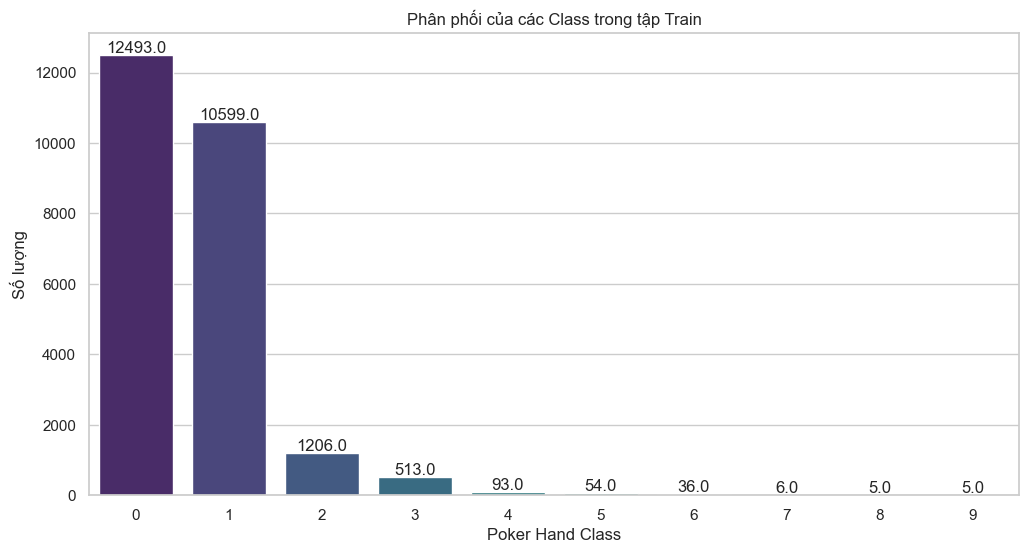

In [5]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_train, x='Class', palette='viridis')
plt.title('Phân phối của các Class trong tập Train')
plt.xlabel('Poker Hand Class')
plt.ylabel('Số lượng')

# Hiển thị số lượng cụ thể trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

**Nhận xét:**
Dữ liệu Poker Hand cực kỳ mất cân bằng (Imbalanced data). Hầu hết các mẫu thuộc về Class 0 (Nothing) và Class 1 (One pair), trong khi các Class cao (Straight flush, Royal flush) rất hiếm. Điều này cần được lưu ý khi đánh giá mô hình.

## 4. Phân phối các Feature (Suits & Ranks)
Kiểm tra xem các thẻ bài có được chia đều đặn không (Uniform distribution).

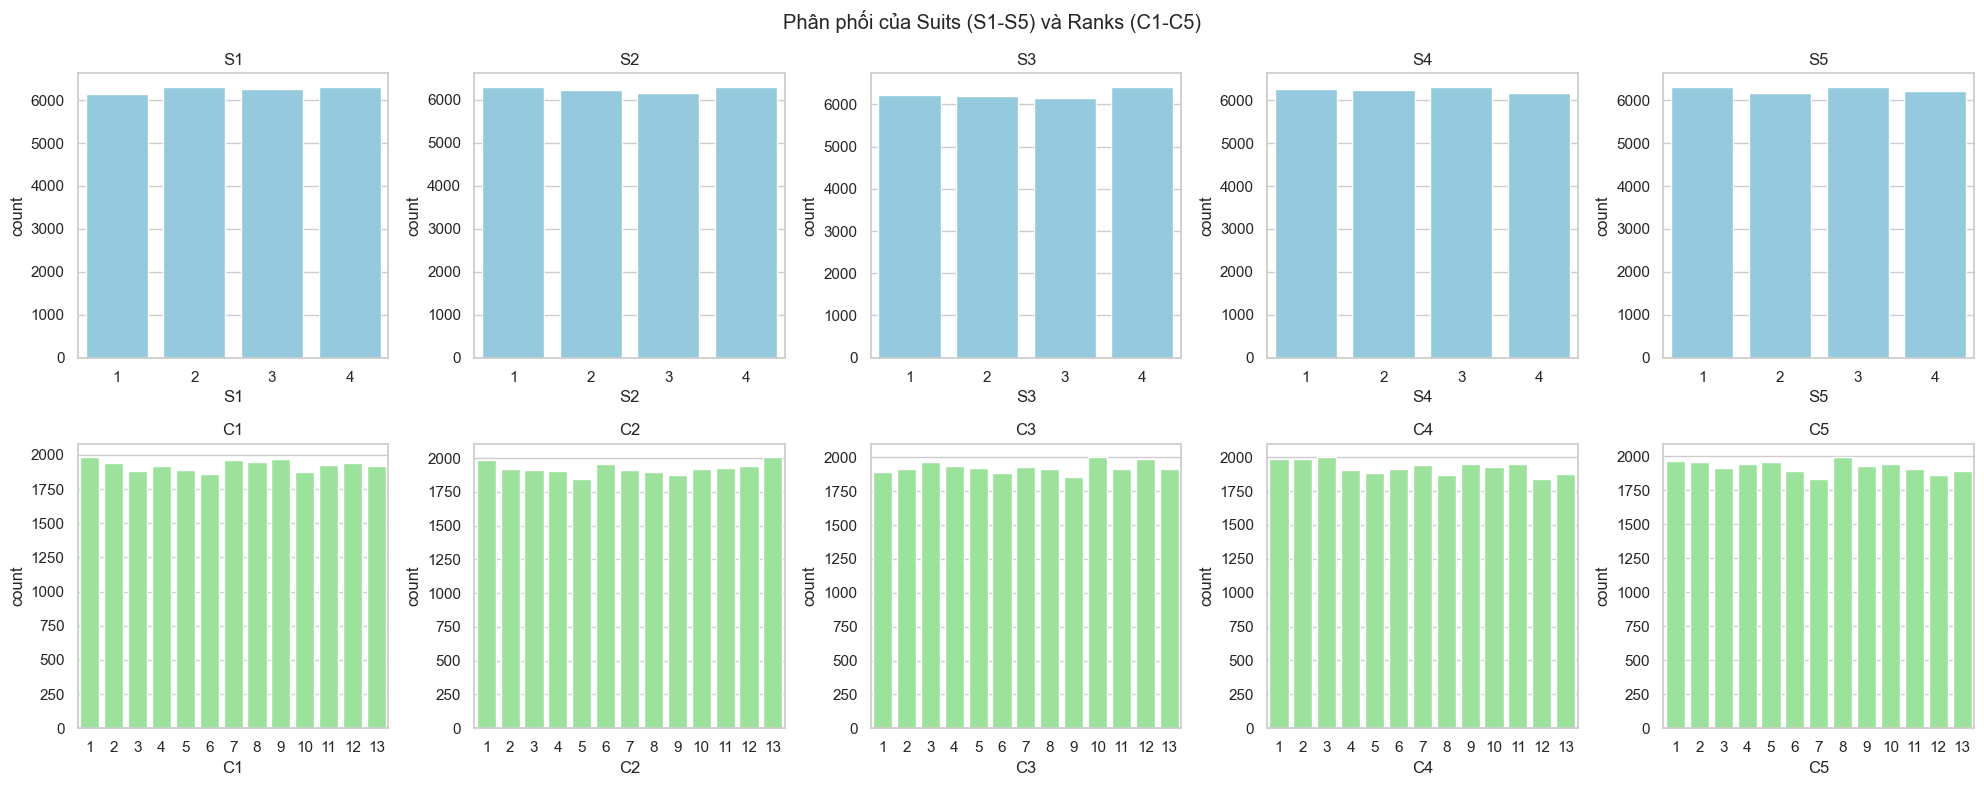

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Phân phối của Suits (S1-S5) và Ranks (C1-C5)')

suits = ['S1', 'S2', 'S3', 'S4', 'S5']
ranks = ['C1', 'C2', 'C3', 'C4', 'C5']

for i, suit in enumerate(suits):
    sns.countplot(data=df_train, x=suit, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(suit)
    
for i, rank in enumerate(ranks):
    sns.countplot(data=df_train, x=rank, ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(rank)
    
plt.tight_layout()
plt.show()

## 5. Mô hình Baseline, Feature Importance và Confusion Matrix
Huấn luyện một mô hình Random Forest cơ bản để đánh giá mức độ quan trọng của các đặc trưng (Feature Importance) và hiển thị Confusion Matrix dưới dạng DataFrame.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tách features và target
X = df_train.drop('Class', axis=1)
y = df_train['Class']

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance
feature_importances = pd.DataFrame(rf.feature_importances_, index=X.columns, columns=['Importance']).sort_values('Importance', ascending=False)
print("Feature Importances:")
display(feature_importances)

# Vẽ đồ thị Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances.index, palette='viridis')
plt.title('Feature Importance')
plt.show()

# Dự đoán và tính Confusion Matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y_test.unique())
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("\nConfusion Matrix (DataFrame):")
display(cm_df)

# Vẽ Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

## 6. Feature Engineering
Tạo thêm các đặc trưng (features) mới dựa trên Ranks (hạng) của các lá bài:
- `unique_rank_count`: Số lượng hạng bài phân biệt trong tay bài.
- `max_same_rank`: Số lá bài nhiều nhất có cùng một hạng.
- `count_pair`: Số lượng đôi (pair) trong tay bài.

In [ ]:
import numpy as np

df_fe = df_train.copy()

# Trích xuất các cột hạng (rank)
ranks = df_fe[['C1', 'C2', 'C3', 'C4', 'C5']].values

unique_rank_count = []
max_same_rank = []
count_pair = []

for row in ranks:
    unique_vals, counts = np.unique(row, return_counts=True)
    unique_rank_count.append(len(unique_vals))
    max_same_rank.append(counts.max())
    count_pair.append(np.sum(counts == 2))

df_fe['unique_rank_count'] = unique_rank_count
df_fe['max_same_rank'] = max_same_rank
df_fe['count_pair'] = count_pair

df_fe.head()

## 7. Đánh giá lại dữ liệu và mô hình sau khi Feature Engineering (như Phần 1)

In [ ]:
X_fe = df_fe.drop('Class', axis=1)
y_fe = df_fe['Class']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

rf_fe = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)

# Feature Importance sau Feature Engineering
feature_importances_fe = pd.DataFrame(rf_fe.feature_importances_, index=X_fe.columns, columns=['Importance']).sort_values('Importance', ascending=False)
print("Feature Importances (Sau Feature Engineering):")
display(feature_importances_fe)

# Vẽ đồ thị Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_fe['Importance'], y=feature_importances_fe.index, palette='viridis')
plt.title('Feature Importance (Sau Feature Engineering)')
plt.show()

# Dự đoán và tính Confusion Matrix
y_pred_fe = rf_fe.predict(X_test_fe)
cm_fe = confusion_matrix(y_test_fe, y_pred_fe)
labels_fe = sorted(y_test_fe.unique())
cm_df_fe = pd.DataFrame(cm_fe, index=labels_fe, columns=labels_fe)
print("\nConfusion Matrix (DataFrame) sau Feature Engineering:")
display(cm_df_fe)

# Vẽ Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_fe, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Sau Feature Engineering)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

## 8. Lưu dữ liệu sau Feature Engineering
Áp dụng Feature Engineering cho cả tập `test.csv` và lưu cả hai tập dữ liệu (train và test) thành các file CSV mới.

In [ ]:
import pandas as pd
import numpy as np

# Lưu tập train đã feature engineering
df_fe.to_csv('train_fe.csv', index=False)

# Đọc tập test và áp dụng Feature Engineering tương tự
df_test = pd.read_csv('test.csv')

ranks_test = df_test[['C1', 'C2', 'C3', 'C4', 'C5']].values

unique_rank_count_test = []
max_same_rank_test = []
count_pair_test = []

for row in ranks_test:
    unique_vals, counts = np.unique(row, return_counts=True)
    unique_rank_count_test.append(len(unique_vals))
    max_same_rank_test.append(counts.max())
    count_pair_test.append(np.sum(counts == 2))

df_test['unique_rank_count'] = unique_rank_count_test
df_test['max_same_rank'] = max_same_rank_test
df_test['count_pair'] = count_pair_test

# Lưu tập test đã feature engineering
df_test.to_csv('test_fe.csv', index=False)
print("Đã lưu thành công train_fe.csv và test_fe.csv")